# Chess Cheating — CPL Matrix Builder
Builds a **2500 cheated x 2500 clean** centipawn-loss matrix from the [Cheat-Net dataset](https://github.com/clarkerubber/Cheat-Net).

- PGNs streamed live from Lichess API, no bulk downloads
- Stockfish via raw subprocess/UCI — `go depth N movetime 500` prevents hangs while staying fast
- CPL tracked from absolute White perspective to avoid sign-flip errors
- Wins only, middlegame moves 11-30, games under 30 target-player moves dropped

### Dependencies
```
pip install chess requests numpy pandas tqdm matplotlib
```

### Outputs
| File | Contents |
|---|---|
| `cpl_matrix.csv` | `username`, `cheating`, `cpl_1` to `cpl_20` |
| `pgn_reference.csv` | `username`, `cheating`, `pgn` (paste into lichess.org/paste to view) |
| `cpl_matrix.npy` | (N x 20) float32 array |
| `labels.npy` | (N,) int8 array, 0=clean 1=cheated |

## Cell 1 - Imports and configuration

In [24]:
import subprocess
import io
import time
import random
import warnings
from pathlib import Path

import chess
import chess.pgn
import numpy as np
import pandas as pd
import requests
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# EDIT THESE
CSV_PATH       = 'player_single_game_data.csv'
STOCKFISH_PATH = r'.\stockfish.exe'
OUTPUT_DIR     = Path('.')

# TUNE THESE
TARGET_PER_CLASS = 2500   # 2500 cheated + 2500 clean
DEPTH            = 12     # Stockfish depth — stops at this OR movetime, whichever first
MOVETIME_MS      = 500    # hard cap per position in milliseconds — prevents hangs
SKIP_MOVES       = 10     # opening moves to skip
N_MOVES          = 20     # middlegame moves to capture
CPL_CAP          = 500    # cap blunders at this centipawn value
MAX_PER_USER     = 50     # max games fetched per Lichess user
API_DELAY        = 2.0    # seconds between Lichess API calls
RANDOM_SEED      = 42

# Expected speed: ~40 evals/game x ~100ms each = ~4 sec/game
# Total estimate: 5000 games x 4 sec = ~6 hours

STOCKFISH_PATH = str(Path(STOCKFISH_PATH).resolve())
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Config loaded')
print(f'  Stockfish : {STOCKFISH_PATH}')
print(f'  Target    : {TARGET_PER_CLASS:,} x 2 = {TARGET_PER_CLASS*2:,} games')
print(f'  Engine    : depth {DEPTH} OR {MOVETIME_MS}ms per position, whichever first')

Config loaded
  Stockfish : C:\Users\James Song.DESKTOP-6EJ6PL1\TDA_chess\final_product\stockfish.exe
  Target    : 2,500 x 2 = 5,000 games
  Engine    : depth 12 OR 500ms per position, whichever first


## Cell 2 - Stockfish wrapper

In [25]:
import queue
import threading

class StockfishDirect:
    """
    Minimal Stockfish wrapper using raw stdin/stdout UCI.
    Uses a background reader thread + queue so readline() can be given a
    hard timeout on any platform (select.select does not work with pipes
    on Windows).
    Supports restart() to recover from crashes without losing the wrapper.
    """
    def __init__(self, path, depth=DEPTH, movetime_ms=MOVETIME_MS, readline_timeout=10.0):
        self.path             = path
        self.depth            = depth
        self.movetime         = movetime_ms
        self.readline_timeout = readline_timeout
        self._start()

    def _start(self):
        """Launch (or re-launch) the Stockfish process and its reader thread."""
        self._q = queue.Queue()
        self.proc = subprocess.Popen(
            self.path,
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.DEVNULL,
            text=True,
            bufsize=1
        )
        self._reader = threading.Thread(target=self._read_loop, daemon=True)
        self._reader.start()
        self._send('uci');     self._wait_for('uciok')
        self._send('isready'); self._wait_for('readyok')

    def restart(self):
        """Kill the current process and start a fresh one. Called on crash."""
        try:
            self.proc.kill()
            self.proc.wait(timeout=3)
        except Exception:
            pass
        print('  [info] Stockfish restarted')
        self._start()

    def _read_loop(self):
        """Runs in a daemon thread; pushes every line into the queue."""
        try:
            for line in self.proc.stdout:
                self._q.put(line)
        except Exception:
            pass
        finally:
            self._q.put(None)  # sentinel: process ended

    def _readline(self):
        """
        Get the next line from Stockfish, blocking up to readline_timeout
        seconds. Raises TimeoutError if nothing arrives in time, or if the
        process has exited (sentinel None received).
        """
        try:
            line = self._q.get(timeout=self.readline_timeout)
        except queue.Empty:
            raise TimeoutError(
                f'Stockfish did not respond within {self.readline_timeout}s'
            )
        if line is None:
            raise TimeoutError('Stockfish process ended unexpectedly')
        return line

    def _send(self, cmd):
        self.proc.stdin.write(cmd + '\n')
        self.proc.stdin.flush()

    def _wait_for(self, token):
        while True:
            if token in self._readline():
                return

    def eval_fen(self, fen):
        self._send(f'position fen {fen}')
        self._send(f'go depth {self.depth} movetime {self.movetime}')
        score = 0
        while True:
            line = self._readline().strip()
            if line.startswith('bestmove'):
                break
            if 'score cp' in line:
                parts = line.split()
                try:
                    idx   = parts.index('cp')
                    score = max(-10000, min(10000, int(parts[idx + 1])))
                except (ValueError, IndexError):
                    pass
            elif 'score mate' in line:
                parts = line.split()
                try:
                    idx   = parts.index('mate')
                    score = 10000 if int(parts[idx + 1]) > 0 else -10000
                except (ValueError, IndexError):
                    pass
        return score

    def new_game(self):
        self._send('ucinewgame')
        self._send('isready')
        self._wait_for('readyok')

    def eval_fen_white(self, fen):
        score = self.eval_fen(fen)
        board = chess.Board(fen)
        return score if board.turn == chess.WHITE else -score

    def close(self):
        try:
            self._send('quit')
            self.proc.wait(timeout=3)
        except Exception:
            self.proc.kill()

    def __enter__(self):  return self
    def __exit__(self, *a): self.close()


print('Testing Stockfish...')
try:
    t0 = time.time()
    with StockfishDirect(STOCKFISH_PATH) as sf:
        score = sf.eval_fen_white(chess.Board().fen())
    elapsed = time.time() - t0
    print(f'  OK - score: {score} cp, took {elapsed:.2f}s')
    print(f'  Estimated speed: ~{40 * elapsed:.0f}s per game')
except FileNotFoundError:
    print(f'  Binary not found at: {STOCKFISH_PATH}')
except Exception as e:
    print(f'  Failed: {e}')


Testing Stockfish...
  OK - score: 47 cp, took 0.30s
  Estimated speed: ~12s per game


## Cell 3 - CPL extraction

In [26]:
def get_player_color(game, username):
    white = game.headers.get('White', '').lower()
    black = game.headers.get('Black', '').lower()
    if username.lower() == white: return chess.WHITE
    if username.lower() == black: return chess.BLACK
    return None


def extract_cpl_sequence(pgn_text, username, sf):
    """
    Returns (cpls, pgn_text) or None.

    If Stockfish times out on a single position the move is skipped.
    If Stockfish crashes entirely (process ended), sf.restart() is called
    and the game is abandoned so the next game gets a fresh engine.
    Terminal positions (checkmate / stalemate) are detected before evaluation
    so Stockfish is never sent a position with no legal moves.
    """
    try:
        game = chess.pgn.read_game(io.StringIO(pgn_text))
        if game is None:
            return None

        color = get_player_color(game, username)
        if color is None:
            return None

        result = game.headers.get('Result', '*')
        player_won = (color == chess.WHITE and result == '1-0') or \
                     (color == chess.BLACK and result == '0-1')
        if not player_won:
            return None

        try:
            sf.new_game()
        except TimeoutError:
            sf.restart()
            return None

        board          = game.board()
        cpls           = []
        our_move_count = 0

        for move in game.mainline_moves():
            if board.turn != color:
                board.push(move)
                continue

            our_move_count += 1
            if our_move_count <= SKIP_MOVES:
                board.push(move)
                continue

            try:
                score_before = sf.eval_fen_white(board.fen())
                board.push(move)

                # Don't ask Stockfish to evaluate a terminal position —
                # checkmate / stalemate produces 'bestmove (none)' which can
                # corrupt the engine state on some builds.
                if board.is_game_over():
                    break

                score_after = sf.eval_fen_white(board.fen())
            except TimeoutError as e:
                err = str(e)
                if 'ended unexpectedly' in err:
                    sf.restart()
                    return None
                board.push(move)
                continue

            if color == chess.WHITE:
                cpl = max(0, score_before - score_after)
            else:
                cpl = max(0, score_after - score_before)

            cpls.append(min(float(cpl), float(CPL_CAP)))

            if len(cpls) == N_MOVES:
                break

        if len(cpls) == N_MOVES:
            return cpls, pgn_text
        return None

    except Exception:
        return None


print('CPL extraction defined')


CPL extraction defined


## Cell 4 - Lichess API helper

In [27]:
# Tallies updated at runtime so the main loop can report them
_api_stats = {'ok': 0, 'not_found': 0, 'rate_limited': 0, 'error': 0}

def fetch_pgns(username, max_games=MAX_PER_USER):
    """
    Stream PGNs from Lichess. Retries up to 3x on 429 with 60s backoff.
    Updates _api_stats so you can see why lookups fail.
    """
    for attempt in range(3):
        try:
            time.sleep(API_DELAY)
            r = requests.get(
                f'https://lichess.org/api/games/user/{username}',
                params={'max': max_games, 'evals': 'false',
                        'clocks': 'false', 'opening': 'false'},
                headers={'Accept': 'application/x-chess-pgn'},
                timeout=30
            )
            if r.status_code == 404:
                _api_stats['not_found'] += 1
                return []
            if r.status_code == 429:
                _api_stats['rate_limited'] += 1
                print(f'  Rate limited — waiting 60s...')
                time.sleep(60)
                continue
            if r.text.strip().startswith('<'):
                _api_stats['not_found'] += 1
                return []
            pgns = [b.strip() for b in r.text.split('\n\n\n') if b.strip()]
            if pgns:
                _api_stats['ok'] += 1
            else:
                _api_stats['not_found'] += 1
            return pgns
        except Exception as e:
            _api_stats['error'] += 1
            print(f'  fetch error ({username}): {e}')
            time.sleep(5)
    return []


print('Testing Lichess API...')
_pgns = fetch_pgns('DrNykterstein', max_games=1)
print(f"  {'OK' if _pgns else 'FAILED'} - got {len(_pgns)} game(s)")


Testing Lichess API...
  OK - got 1 game(s)


## Cell 5 - Speed + CPL smoke test
Run this before the full pipeline to verify speed and CPL values are sane.
Expected: ~2-6 sec/game, mean CPL under 20 for a known cheater.

In [28]:
test_user = 'esmaytou'
test_pgns = fetch_pgns(test_user, max_games=50)
print(f'Fetched {len(test_pgns)} games\n')

with StockfishDirect(STOCKFISH_PATH) as sf:
    for i, pgn_text in enumerate(test_pgns):
        t0 = time.time()
        result = extract_cpl_sequence(pgn_text, test_user, sf)
        elapsed = time.time() - t0
        if result is not None:
            cpls, pgn = result
            mean_cpl = sum(cpls) / len(cpls)
            print(f'Game #{i+1} passed in {elapsed:.1f}s')
            print(f'  CPLs : {[round(c) for c in cpls]}')
            print(f'  Mean : {mean_cpl:.1f} cp  (expect < 20 for cheater)')
            print(f'  Est. full run: {elapsed * TARGET_PER_CLASS * 2 / 3600:.1f} hours at this speed')
            break
    else:
        print('No passing games found')

Fetched 27 games

Game #1 passed in 0.3s
  CPLs : [21, 0, 0, 22, 23, 6, 4, 62, 116, 0, 131, 10, 37, 30, 91, 0, 0, 22, 7, 0]
  Mean : 29.1 cp  (expect < 20 for cheater)
  Est. full run: 0.4 hours at this speed


## Cell 6 - Load player list

In [29]:
df_src = pd.read_csv(CSV_PATH)

players = (
    df_src[['name', 'cheating']]
    .drop_duplicates()
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

cheater_names = players[players['cheating'] == 1]['name'].tolist()
clean_names   = players[players['cheating'] == 0]['name'].tolist()

print(f'Unique players : {len(players):,}')
print(f'  Cheaters     : {len(cheater_names):,}')
print(f'  Clean        : {len(clean_names):,}')

Unique players : 5,559
  Cheaters     : 2,270
  Clean        : 3,289


## Cell 7 - Run the pipeline
Run cell 5 first to confirm speed before committing to the full run.

In [30]:
rows_cheated = []
rows_clean   = []
failed       = []
_api_stats   = {'ok': 0, 'not_found': 0, 'rate_limited': 0, 'error': 0}

max_users = max(len(cheater_names), len(clean_names))
pbar = tqdm(total=TARGET_PER_CLASS * 2, desc='Games collected', unit='game')

with StockfishDirect(STOCKFISH_PATH) as sf:
    for i in range(max_users):

        if len(rows_cheated) >= TARGET_PER_CLASS and len(rows_clean) >= TARGET_PER_CLASS:
            break

        for username, is_cheater, bucket, target in [
            (cheater_names[i] if i < len(cheater_names) else None, 1, rows_cheated, TARGET_PER_CLASS),
            (clean_names[i]   if i < len(clean_names)   else None, 0, rows_clean,   TARGET_PER_CLASS),
        ]:
            if username is None or len(bucket) >= target:
                continue

            pgns = fetch_pgns(username)
            if not pgns:
                failed.append(username)
                continue

            for pgn_text in pgns:
                if len(bucket) >= target:
                    break
                result = extract_cpl_sequence(pgn_text, username, sf)
                if result is None:
                    continue
                cpls, pgn = result
                bucket.append({
                    'username': username,
                    'cheating': is_cheater,
                    'pgn':      pgn,
                    **{f'cpl_{j+1}': v for j, v in enumerate(cpls)},
                })
                pbar.update(1)

pbar.close()
print(f'\nDone - {len(rows_cheated)} cheated, {len(rows_clean)} clean')
print(f'\nAPI lookup breakdown:')
print(f'  OK (had games)   : {_api_stats["ok"]:,}')
print(f'  Not found / empty: {_api_stats["not_found"]:,}')
print(f'  Rate limited     : {_api_stats["rate_limited"]:,}')
print(f'  Network errors   : {_api_stats["error"]:,}')
print(f'  Failed total     : {len(failed):,}')


Games collected:   0%|          | 0/5000 [00:00<?, ?game/s]

  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stockfish restarted
  [info] Stock

## Cell 8 - Assemble dataframe and sanity check

In [31]:
df = (
    pd.DataFrame(rows_cheated + rows_clean)
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

cpl_cols = [f'cpl_{i+1}' for i in range(N_MOVES)]

print(f'Matrix shape  : {df.shape}')
print(f'Class balance : {df["cheating"].value_counts().to_dict()}')
print(f'Mean CPL (cheated) : {df[df["cheating"]==1][cpl_cols].values.mean():.1f} cp  (expect < 20)')
print(f'Mean CPL (clean)   : {df[df["cheating"]==0][cpl_cols].values.mean():.1f} cp  (expect > 35)')
df[['username', 'cheating'] + cpl_cols].head(3)

Matrix shape  : (5000, 23)
Class balance : {1: 2500, 0: 2500}
Mean CPL (cheated) : 36.9 cp  (expect < 20)
Mean CPL (clean)   : 50.3 cp  (expect > 35)


,username,cheating,cpl_1,cpl_2,cpl_3,cpl_4,cpl_5,cpl_6,cpl_7,cpl_8,...,cpl_11,cpl_12,cpl_13,cpl_14,cpl_15,cpl_16,cpl_17,cpl_18,cpl_19,cpl_20
0,telbat,1,0.0,9.0,1.0,57.0,2.0,13.0,16.0,0.0,...,25.0,0.0,48.0,48.0,1.0,43.0,0.0,0.0,26.0,62.0
1,nottoblame,0,372.0,25.0,43.0,440.0,11.0,21.0,15.0,45.0,...,54.0,3.0,0.0,19.0,0.0,123.0,0.0,36.0,0.0,0.0
2,sundoroclasic,0,65.0,0.0,90.0,59.0,65.0,0.0,55.0,35.0,...,164.0,0.0,24.0,0.0,6.0,0.0,2.0,93.0,42.0,4.0


## Cell 9 - Save outputs

In [32]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cpl_cols = [f'cpl_{i+1}' for i in range(N_MOVES)]

cpl_path = OUTPUT_DIR / 'cpl_matrix.csv'
df[['username', 'cheating'] + cpl_cols].to_csv(cpl_path, index=False)
print(f'CPL matrix    -> {cpl_path}')

pgn_path = OUTPUT_DIR / 'pgn_reference.csv'
df[['username', 'cheating', 'pgn']].to_csv(pgn_path, index=False)
print(f'PGN reference -> {pgn_path}')

X = df[cpl_cols].to_numpy(dtype=np.float32)
y = df['cheating'].to_numpy(dtype=np.int8)
np.save(OUTPUT_DIR / 'cpl_matrix.npy', X)
np.save(OUTPUT_DIR / 'labels.npy', y)
print(f'Numpy matrix  -> cpl_matrix.npy  shape={X.shape}')
print(f'Labels        -> labels.npy       shape={y.shape}')

if failed:
    fail_path = OUTPUT_DIR / 'failed_users.txt'
    fail_path.write_text('\n'.join(failed))
    print(f'Failed users  -> {fail_path} ({len(failed)} users)')

CPL matrix    -> cpl_matrix.csv
PGN reference -> pgn_reference.csv
Numpy matrix  -> cpl_matrix.npy  shape=(5000, 20)
Labels        -> labels.npy       shape=(5000,)
Failed users  -> failed_users.txt (126 users)


## Cell 10 - Visualisation

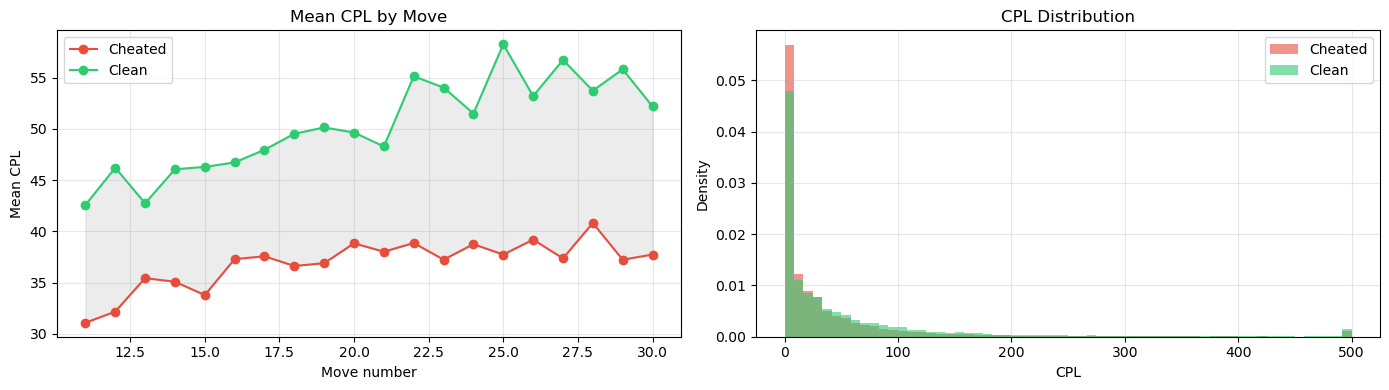

Saved -> cpl_viz.png


In [33]:
import matplotlib.pyplot as plt

cpl_cols    = [f'cpl_{i+1}' for i in range(N_MOVES)]
cheat_means = df[df['cheating'] == 1][cpl_cols].mean()
clean_means = df[df['cheating'] == 0][cpl_cols].mean()
move_nums   = list(range(SKIP_MOVES + 1, SKIP_MOVES + N_MOVES + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(move_nums, cheat_means.values, marker='o', label='Cheated', color='#e74c3c')
ax.plot(move_nums, clean_means.values, marker='o', label='Clean',   color='#2ecc71')
ax.fill_between(move_nums, cheat_means.values, clean_means.values, alpha=0.15, color='gray')
ax.set_xlabel('Move number'); ax.set_ylabel('Mean CPL')
ax.set_title('Mean CPL by Move'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(df[df['cheating']==1][cpl_cols].values.flatten(),
        bins=60, alpha=0.6, label='Cheated', color='#e74c3c', density=True)
ax.hist(df[df['cheating']==0][cpl_cols].values.flatten(),
        bins=60, alpha=0.6, label='Clean',   color='#2ecc71', density=True)
ax.set_xlabel('CPL'); ax.set_ylabel('Density')
ax.set_title('CPL Distribution'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cpl_viz.png', dpi=150)
plt.show()
print('Saved -> cpl_viz.png')

## Cell 11 - Reload saved data for later sessions

In [34]:
# Run this instead of cells 7-9 if the matrix is already built
# X       = np.load('cpl_matrix.npy')
# y       = np.load('labels.npy')
# df      = pd.read_csv('cpl_matrix.csv')
# df_pgns = pd.read_csv('pgn_reference.csv')
# print(f'Loaded: X={X.shape}, y={y.shape}')